In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000328_08_03_180.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000223_09_02_146.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000229_03_04_202.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000103_01_01_104.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000103_12_01_075.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000143_04_02_153.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/002276_05_03_078.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000020_03_01_166.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000054_03_01_025.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000230_04_01_242.png


In [2]:
%config Completer.use_jedi = False
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import seaborn as sns
import cv2
import random
import os
import imageio
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, RepeatedStratifiedKFold
from imblearn.over_sampling import SMOTE

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from keras.applications import resnet
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3, EfficientNetB4, EfficientNetB5, EfficientNetB6, EfficientNetB7
from keras.applications.resnet import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img


2026-04-12 14:36:21.027773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776004581.248235      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776004581.308766      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776004581.820494      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776004581.820539      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776004581.820564      55 computation_placer.cc:177] computation placer alr

In [3]:
directory = r'/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset'

categories = ['Bengin cases', 'Malignant cases', 'Normal cases']

Bengin cases - Bengin case (97).jpg
Malignant cases - Malignant case (79).jpg
Normal cases - Normal case (246).jpg


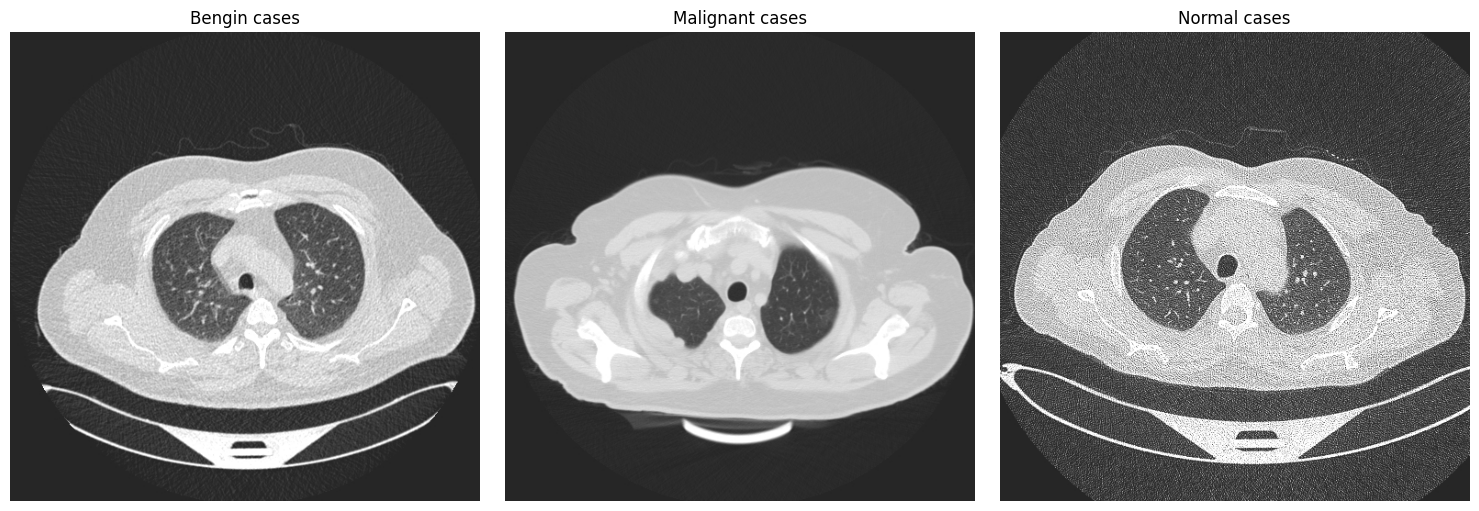

In [4]:
fig, axes = plt.subplots(1, len(categories), figsize=(15, 5))

for i, category in enumerate(categories):
    path = os.path.join(directory, category)
    # Loop files but break after the first one to show just one sample
    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        print(category, '-', file)

        # Baca image asli (BGR) dan konversi ke RGB
        img = cv2.imread(filepath)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Tampilkan di subplot yang sesuai
        axes[i].imshow(img)
        axes[i].set_title(f'{category}')
        axes[i].axis('off')
        break

plt.tight_layout()
plt.show()

In [5]:
size_data = {}
for i in categories:
    path = os.path.join(directory, i)
    class_num = categories.index(i)
    temp_dict = {}
    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        height, width, channels = imageio.imread(filepath).shape
        if str(height) + ' x ' + str(width) in temp_dict:
            temp_dict[str(height) + ' x ' + str(width)] += 1
        else:
            temp_dict[str(height) + ' x ' + str(width)] = 1

    size_data[i] = temp_dict

size_data

/tmp/ipykernel_55/73549651.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  height, width, channels = imageio.imread(filepath).shape


{'Bengin cases': {'512 x 512': 120},
 'Malignant cases': {'512 x 512': 501,
  '512 x 623': 31,
  '512 x 801': 28,
  '404 x 511': 1},
 'Normal cases': {'512 x 512': 415, '331 x 506': 1}}

In [6]:
import os, cv2, random
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Inisialisasi
data = []
img_size = 224 # WAJIB 224 untuk MobileNetV2

# Pastikan variabel 'categories' dan 'directory' sudah didefinisikan sebelumnya
for i in categories:
    path = os.path.join(directory, i)
    class_num = categories.index(i)

    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        # Konversi ke RGB karena MobileNetV2 mengharapkan 3 channel
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        data.append([img, class_num])

# Shuffle untuk memastikan variasi data saat splitting
random.shuffle(data)

# Memisahkan fitur (X) dan label (y)
X, y = zip(*data)
X = np.array(X, dtype=np.float32)
y = np.array(y)

print('--- Data Loaded ---')
print('Total X shape:', X.shape)
print('Label distribution:', Counter(y))

--- Data Loaded ---
Total X shape: (1097, 224, 224, 3)
Label distribution: Counter({np.int64(1): 561, np.int64(2): 416, np.int64(0): 120})


In [7]:
# 1. SPLIT DATA → 70% TRAIN, 15% VALID, 15% TEST
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=10, 
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=10, 
    stratify=y_temp
)

# 2. PREPROCESS (Scaling pixel ke range yang sesuai MobileNetV2)
# X_train = preprocess_input(X_train)
# X_valid = preprocess_input(X_valid)
# X_test  = preprocess_input(X_test)

# 3. CLASS WEIGHT (Mencegah imbalance pada training)
counter = Counter(y_train)
total = len(y_train)
num_classes = len(categories)

class_weights = {i: total / (num_classes * counter[i]) for i in counter}

# 4. ONE HOT ENCODING
y_train = to_categorical(y_train, num_classes=num_classes)
y_valid = to_categorical(y_valid, num_classes=num_classes)
y_test  = to_categorical(y_test,  num_classes=num_classes)

print("--- Preprocessing Complete ---")
print("Class weights:", class_weights)
print("Train shape :", X_train.shape, y_train.shape)
print("Valid shape :", X_valid.shape, y_valid.shape)
print("Test  shape :", X_test.shape,  y_test.shape)

--- Preprocessing Complete ---
Class weights: {np.int64(2): 0.8785796105383734, np.int64(1): 0.6522108843537415, np.int64(0): 3.0436507936507935}
Train shape : (767, 224, 224, 3) (767, 3)
Valid shape : (165, 224, 224, 3) (165, 3)
Test  shape : (165, 224, 224, 3) (165, 3)


Building CNN + Attention Model


Model: "CNN_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_20            │ (None, 224, 224, 64)   │         1,096 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_21            │ (None, 112, 112, 64)   │         1,096 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 16)             │     3,211,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,252,243 (12.41 MB)

 Trainable params: 3,252,243 (12.41 MB)

 Non-trainable params: 0 (0.00 B)


Training Base Model
Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.4694 - loss: 114.4008 - val_accuracy: 0.7091 - val_loss: 1.6120
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.6309 - loss: 1.1379 - val_accuracy: 0.6000 - val_loss: 1.0209
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.6286 - loss: 0.8351 - val_accuracy: 0.7576 - val_loss: 0.5925
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.8390 - loss: 0.3767 - val_accuracy: 0.8667 - val_loss: 0.3279
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.8975 - loss: 0.1748 - val_accuracy: 0.8667 - val_loss: 0.2570
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.8902 - loss: 0.1392 - val_accuracy: 0.8667 - val_loss: 0.2490
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.9033 - loss: 0.1303 - val_accuracy: 0.9212 - val_loss: 0.2305
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.9926 - loss: 0.1638 - val_accur

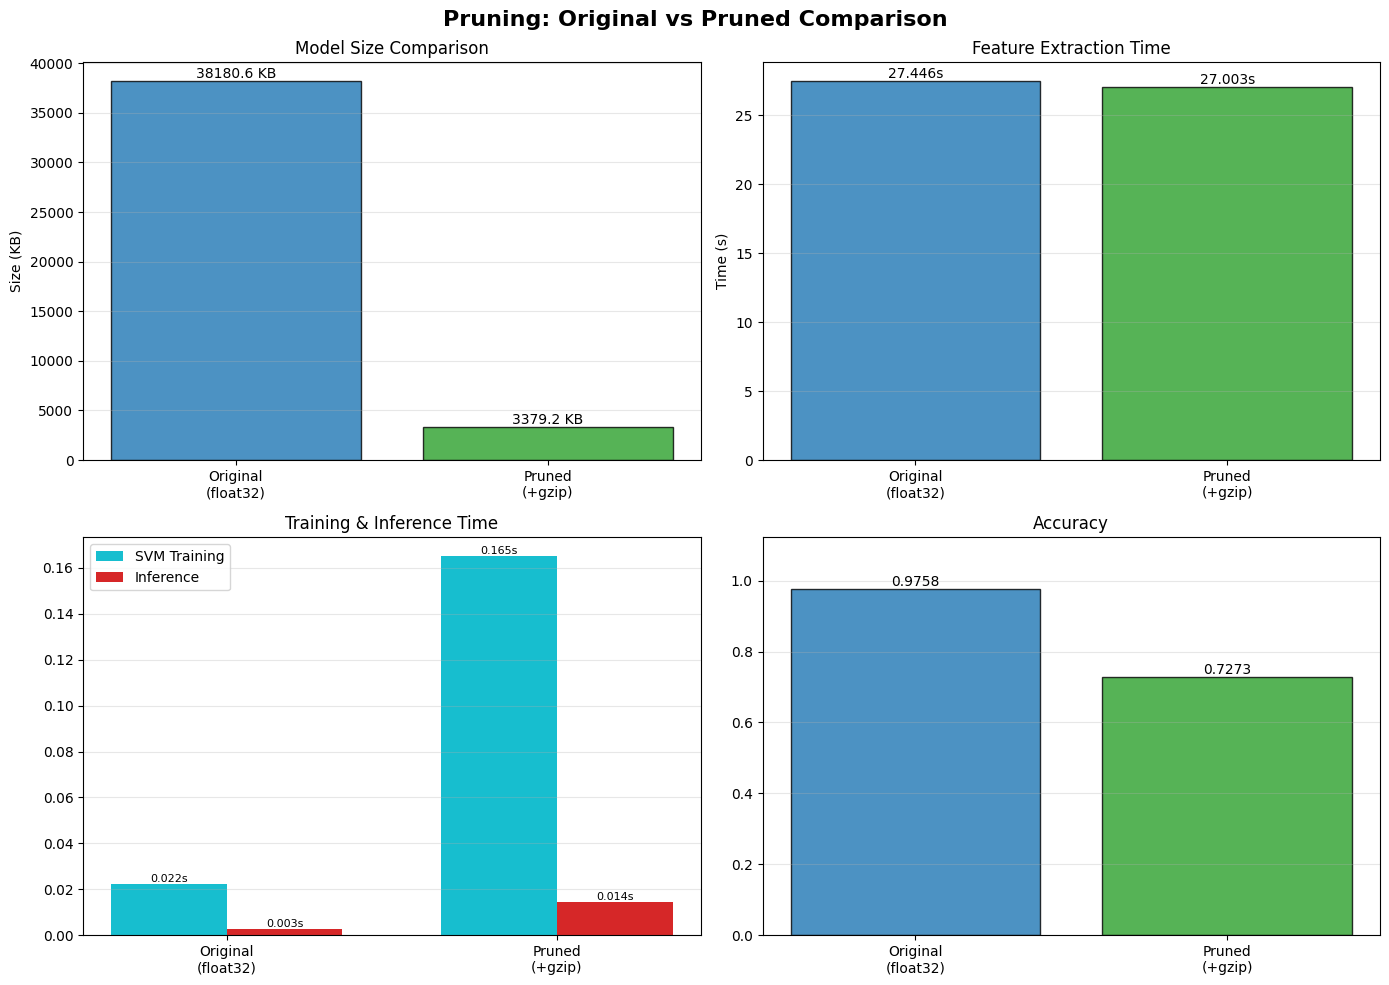


TABEL UKURAN MODEL / ARTEFAK
                  Komponen  Awal (KB)  Setelah Pruning (KB)  Setelah Pruning + GZIP (KB)
      CNN Attention (main)  38,180.59             12,761.24                     3,379.17
     CNN Feature Extractor  12,754.47             12,754.23                     3,378.32
   SVM (original features)      10.85                 10.85                        10.85
Scaler (original features)       0.98                  0.98                         0.98
     SVM (pruned features)      92.52                 92.52                        92.52
  Scaler (pruned features)       0.98                  0.98                         0.98
                     TOTAL  51,040.38             25,620.78                     6,862.81

FINAL SUMMARY

Metric                         Original           Pruned (+gzip)    
--------------------------------------------------------------------------------
Model Size (KB)                     38180.6             3379.2
Feature Extraction (s)       

In [20]:
"""
Complete CNN + Attention + SVM Pipeline with Pruning
Trains original float32 model, applies pruning, compares both.
"""

import os
import time
import gzip
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     GlobalAveragePooling2D, Reshape,
                                     Multiply, Input, Layer)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

try:
    import tensorflow_model_optimization as tfmot
    _TFMOT_AVAILABLE = True
except Exception:
    _TFMOT_AVAILABLE = False


# ===========================================================================
# PART A: MODEL DEFINITION
# ===========================================================================
class ChannelAttention(Layer):
    """Custom Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = GlobalAveragePooling2D()
        self.dense1 = Dense(max(1, channels // self.ratio), activation='relu')
        self.dense2 = Dense(channels, activation='sigmoid')
        self.reshape = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config


def build_cnn_attention_model(input_shape, num_classes):
    """Build CNN + Attention model"""
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    features = Dense(16, activation='relu', name='feature_layer')(x)
    output = Dense(num_classes, activation='softmax', name='softmax_output')(features)

    return Model(inputs, output, name='CNN_Attention')


# ===========================================================================
# PART B: PRUNING HELPERS
# ===========================================================================
def _gzip_file(src_path, dst_path):
    with open(src_path, 'rb') as f_in, gzip.open(dst_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)


def _build_pruning_masks(weight_list, target_sparsity=0.80):
    masks = []
    for w in weight_list:
        if w.ndim >= 2:
            abs_flat = np.abs(w).flatten()
            if abs_flat.size == 0:
                masks.append(np.ones_like(w, dtype=np.float32))
                continue
            threshold = np.percentile(abs_flat, target_sparsity * 100.0)
            mask = (np.abs(w) >= threshold).astype(np.float32)
            masks.append(mask)
        else:
            masks.append(np.ones_like(w, dtype=np.float32))
    return masks


def _apply_masks(weight_list, masks):
    return [w * m for w, m in zip(weight_list, masks)]


class SparsityMaskCallback(tf.keras.callbacks.Callback):
    def __init__(self, masks):
        super().__init__()
        self.masks = masks

    def on_train_batch_end(self, batch, logs=None):
        weights = self.model.get_weights()
        self.model.set_weights(_apply_masks(weights, self.masks))


def _create_pruned_model(model, final_sparsity, prune_epochs, batch_size, X_train):
    """
    Try tfmot pruning first. If environment is incompatible, fallback to manual masking.
    Returns: pruned_model, callbacks, mode_name
    """
    if _TFMOT_AVAILABLE:
        try:
            end_step = int(np.ceil(len(X_train) / batch_size) * prune_epochs)
            schedule = tfmot.sparsity.keras.PolynomialDecay(
                initial_sparsity=0.30,
                final_sparsity=final_sparsity,
                begin_step=0,
                end_step=max(1, end_step),
            )
            pruned_model = tfmot.sparsity.keras.prune_low_magnitude(
                model,
                pruning_schedule=schedule,
            )
            callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]
            return pruned_model, callbacks, "tfmot"
        except Exception as e:
            print(f"[Pruning] tfmot fallback aktif karena: {e}")

    # Fallback manual masking
    pruned_model = tf.keras.models.clone_model(model)
    pruned_model.build(model.input_shape)
    pruned_model.set_weights(model.get_weights())

    masks = _build_pruning_masks(pruned_model.get_weights(), target_sparsity=final_sparsity)
    pruned_model.set_weights(_apply_masks(pruned_model.get_weights(), masks))
    callbacks = [SparsityMaskCallback(masks)]
    return pruned_model, callbacks, "manual-mask"


def setup_pruning_pipeline(model, X_train, X_valid, y_train, y_valid,
                           batch_size=32, prune_epochs=5, final_sparsity=0.80):
    """
    Build size artifacts for 3 stages:
    1) Original format
    2) Pruned model (stripped if tfmot)
    3) Pruned model + compression (gzip)
    """
    os.makedirs("artifacts", exist_ok=True)

    extractor_orig = Model(
        inputs=model.input,
        outputs=model.get_layer('feature_layer').output,
    )

    # Stage 1
    cnn_keras_path = "artifacts/cnn_attention_model.keras"
    ext_keras_path = "artifacts/cnn_attention_extractor.keras"
    model.save(cnn_keras_path)
    extractor_orig.save(ext_keras_path)
    print(f"[Pruning] Original CNN saved -> {cnn_keras_path}")
    print(f"[Pruning] Original extractor saved -> {ext_keras_path}")

    # Stage 2
    pruned_model, prune_callbacks, prune_mode = _create_pruned_model(
        model=model,
        final_sparsity=final_sparsity,
        prune_epochs=prune_epochs,
        batch_size=batch_size,
        X_train=X_train,
    )

    pruned_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print(f"[Pruning] Fine-tuning mode: {prune_mode}")
    t0 = time.time()
    history_prune = pruned_model.fit(
        X_train, y_train,
        epochs=prune_epochs,
        batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=prune_callbacks + [EarlyStopping(patience=2, restore_best_weights=True, monitor='val_loss')],
        verbose=1,
    )
    pruning_finetune_time = time.time() - t0
    print(f"[Pruning] Fine-tune time: {pruning_finetune_time:.3f} s")

    if _TFMOT_AVAILABLE and prune_mode == "tfmot":
        stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)
    else:
        stripped_model = pruned_model

    stripped_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    extractor_pruned = Model(
        inputs=stripped_model.input,
        outputs=stripped_model.get_layer('feature_layer').output,
    )

    cnn_pruned_path = "artifacts/cnn_attention_pruned.keras"
    ext_pruned_path = "artifacts/cnn_attention_extractor_pruned.keras"
    stripped_model.save(cnn_pruned_path)
    extractor_pruned.save(ext_pruned_path)

    cnn_pruned_gz_path = "artifacts/cnn_attention_pruned.keras.gz"
    ext_pruned_gz_path = "artifacts/cnn_attention_extractor_pruned.keras.gz"
    _gzip_file(cnn_pruned_path, cnn_pruned_gz_path)
    _gzip_file(ext_pruned_path, ext_pruned_gz_path)

    artifact_paths = {
        'cnn_keras': cnn_keras_path,
        'extractor_keras': ext_keras_path,
        'cnn_pruned': cnn_pruned_path,
        'extractor_pruned': ext_pruned_path,
        'cnn_pruned_gz': cnn_pruned_gz_path,
        'extractor_pruned_gz': ext_pruned_gz_path,
    }

    return artifact_paths, stripped_model, extractor_pruned, history_prune, pruning_finetune_time


def extract_features_keras(extractor_model, X):
    return extractor_model.predict(X, verbose=0)


def _file_size_kb(path):
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else 0.0


def build_size_table(artifact_paths, svm_orig_path, scaler_orig_path, svm_pruned_path, scaler_pruned_path):
    rows = [
        {
            'Komponen': 'CNN Attention (main)',
            'Awal (KB)': _file_size_kb(artifact_paths['cnn_keras']),
            'Setelah Pruning (KB)': _file_size_kb(artifact_paths['cnn_pruned']),
            'Setelah Pruning + GZIP (KB)': _file_size_kb(artifact_paths['cnn_pruned_gz']),
        },
        {
            'Komponen': 'CNN Feature Extractor',
            'Awal (KB)': _file_size_kb(artifact_paths['extractor_keras']),
            'Setelah Pruning (KB)': _file_size_kb(artifact_paths['extractor_pruned']),
            'Setelah Pruning + GZIP (KB)': _file_size_kb(artifact_paths['extractor_pruned_gz']),
        },
        {
            'Komponen': 'SVM (original features)',
            'Awal (KB)': _file_size_kb(svm_orig_path),
            'Setelah Pruning (KB)': _file_size_kb(svm_orig_path),
            'Setelah Pruning + GZIP (KB)': _file_size_kb(svm_orig_path),
        },
        {
            'Komponen': 'Scaler (original features)',
            'Awal (KB)': _file_size_kb(scaler_orig_path),
            'Setelah Pruning (KB)': _file_size_kb(scaler_orig_path),
            'Setelah Pruning + GZIP (KB)': _file_size_kb(scaler_orig_path),
        },
        {
            'Komponen': 'SVM (pruned features)',
            'Awal (KB)': _file_size_kb(svm_pruned_path),
            'Setelah Pruning (KB)': _file_size_kb(svm_pruned_path),
            'Setelah Pruning + GZIP (KB)': _file_size_kb(svm_pruned_path),
        },
        {
            'Komponen': 'Scaler (pruned features)',
            'Awal (KB)': _file_size_kb(scaler_pruned_path),
            'Setelah Pruning (KB)': _file_size_kb(scaler_pruned_path),
            'Setelah Pruning + GZIP (KB)': _file_size_kb(scaler_pruned_path),
        },
    ]
    df = pd.DataFrame(rows)
    total_row = {
        'Komponen': 'TOTAL',
        'Awal (KB)': df['Awal (KB)'].sum(),
        'Setelah Pruning (KB)': df['Setelah Pruning (KB)'].sum(),
        'Setelah Pruning + GZIP (KB)': df['Setelah Pruning + GZIP (KB)'].sum(),
    }
    return pd.concat([df, pd.DataFrame([total_row])], ignore_index=True)


def print_size_table(size_df):
    print("\n" + "=" * 105)
    print("TABEL UKURAN MODEL / ARTEFAK")
    print("=" * 105)
    with pd.option_context('display.max_colwidth', None, 'display.float_format', '{:,.2f}'.format):
        print(size_df.to_string(index=False))
    print("=" * 105)


# ===========================================================================
# PART C: PIPELINE EXECUTION
# ===========================================================================
def run_complete_pipeline(model, X_train, X_valid, X_test,
                         y_train, y_valid, y_test):
    y_train_int = np.argmax(y_train, axis=1)
    y_valid_int = np.argmax(y_valid, axis=1)
    y_test_int = np.argmax(y_test, axis=1)

    artifact_paths, pruned_model, extractor_pruned, history_prune, pruning_finetune_time = setup_pruning_pipeline(
        model, X_train, X_valid, y_train, y_valid
    )

    print("\n" + "=" * 70)
    print("PIPELINE A: ORIGINAL MODEL (float32)")
    print("=" * 70)

    size_orig_kb = _file_size_kb(artifact_paths['cnn_keras'])

    extractor_orig = Model(inputs=model.input, outputs=model.get_layer('feature_layer').output)
    t0 = time.time()
    X_train_feat_orig = extract_features_keras(extractor_orig, X_train)
    X_val_feat_orig = extract_features_keras(extractor_orig, X_valid)
    X_test_feat_orig = extract_features_keras(extractor_orig, X_test)
    t_feat_orig = time.time() - t0

    scaler_orig = StandardScaler()
    X_train_scaled_orig = scaler_orig.fit_transform(X_train_feat_orig)
    X_val_scaled_orig = scaler_orig.transform(X_val_feat_orig)
    X_test_scaled_orig = scaler_orig.transform(X_test_feat_orig)

    X_svm_train_orig = np.vstack([X_train_scaled_orig, X_val_scaled_orig])
    y_svm_train_orig = np.concatenate([y_train_int, y_valid_int])

    t0 = time.time()
    svm_orig = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    svm_orig.fit(X_svm_train_orig, y_svm_train_orig)
    t_svm_orig = time.time() - t0

    t0 = time.time()
    y_pred_orig = svm_orig.predict(X_test_scaled_orig)
    y_proba_orig = svm_orig.predict_proba(X_test_scaled_orig)
    t_inf_orig = time.time() - t0

    acc_orig = accuracy_score(y_test_int, y_pred_orig)
    print(f"Model size: {size_orig_kb:.1f} KB")
    print(f"Feature extraction time: {t_feat_orig:.3f} s")
    print(f"SVM training time: {t_svm_orig:.3f} s")
    print(f"Inference time: {t_inf_orig:.4f} s")
    print(f"Test accuracy: {acc_orig:.4f}")

    print("\n" + "=" * 70)
    print("PIPELINE B: PRUNED MODEL")
    print("=" * 70)

    size_pruned_kb = _file_size_kb(artifact_paths['cnn_pruned'])
    size_pruned_gz_kb = _file_size_kb(artifact_paths['cnn_pruned_gz'])

    t0 = time.time()
    X_train_feat_pruned = extract_features_keras(extractor_pruned, X_train)
    X_val_feat_pruned = extract_features_keras(extractor_pruned, X_valid)
    X_test_feat_pruned = extract_features_keras(extractor_pruned, X_test)
    t_feat_pruned = time.time() - t0

    scaler_pruned = StandardScaler()
    X_train_scaled_pruned = scaler_pruned.fit_transform(X_train_feat_pruned)
    X_val_scaled_pruned = scaler_pruned.transform(X_val_feat_pruned)
    X_test_scaled_pruned = scaler_pruned.transform(X_test_feat_pruned)

    X_svm_train_pruned = np.vstack([X_train_scaled_pruned, X_val_scaled_pruned])
    y_svm_train_pruned = np.concatenate([y_train_int, y_valid_int])

    t0 = time.time()
    svm_pruned = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    svm_pruned.fit(X_svm_train_pruned, y_svm_train_pruned)
    t_svm_pruned = time.time() - t0

    t0 = time.time()
    y_pred_pruned = svm_pruned.predict(X_test_scaled_pruned)
    y_proba_pruned = svm_pruned.predict_proba(X_test_scaled_pruned)
    t_inf_pruned = time.time() - t0

    acc_pruned = accuracy_score(y_test_int, y_pred_pruned)
    print(f"Model size (pruned .keras): {size_pruned_kb:.1f} KB")
    print(f"Model size (pruned .keras.gz): {size_pruned_gz_kb:.1f} KB")
    print(f"Feature extraction time: {t_feat_pruned:.3f} s")
    print(f"SVM training time: {t_svm_pruned:.3f} s")
    print(f"Inference time: {t_inf_pruned:.4f} s")
    print(f"Test accuracy: {acc_pruned:.4f}")

    os.makedirs("artifacts", exist_ok=True)
    svm_orig_path = "artifacts/svm_original.pkl"
    scaler_orig_path = "artifacts/scaler_original.pkl"
    svm_pruned_path = "artifacts/svm_pruned.pkl"
    scaler_pruned_path = "artifacts/scaler_pruned.pkl"

    joblib.dump(svm_orig, svm_orig_path)
    joblib.dump(scaler_orig, scaler_orig_path)
    joblib.dump(svm_pruned, svm_pruned_path)
    joblib.dump(scaler_pruned, scaler_pruned_path)

    size_df = build_size_table(
        artifact_paths,
        svm_orig_path,
        scaler_orig_path,
        svm_pruned_path,
        scaler_pruned_path,
    )

    metrics = {
        'size_kb': [size_orig_kb, size_pruned_gz_kb],
        'size_pruned_raw_kb': [size_orig_kb, size_pruned_kb],
        't_feature': [t_feat_orig, t_feat_pruned],
        't_svm': [t_svm_orig, t_svm_pruned],
        't_infer': [t_inf_orig, t_inf_pruned],
        'accuracy': [acc_orig, acc_pruned],
        'pruning_finetune_time': pruning_finetune_time,
    }

    eval_data = (y_test_int, y_pred_orig, y_pred_pruned, y_proba_orig, y_proba_pruned)

    # Keep old variable names for compatibility with evaluation cells.
    globals()['y_test_int'] = y_test_int
    globals()['y_pred_orig'] = y_pred_orig
    globals()['y_pred_pruned'] = y_pred_pruned
    globals()['y_proba_orig'] = y_proba_orig
    globals()['y_proba_pruned'] = y_proba_pruned

    globals()['y_pred_ptq'] = y_pred_pruned
    globals()['y_proba_ptq'] = y_proba_pruned
    globals()['t_svm_orig'] = t_svm_orig
    globals()['t_svm_ptq'] = t_svm_pruned

    print("\nClassification Report (Original):")
    print(classification_report(y_test_int, y_pred_orig, zero_division=0))
    print("\nClassification Report (Pruned):")
    print(classification_report(y_test_int, y_pred_pruned, zero_division=0))

    return metrics, eval_data, size_df, history_prune


# ===========================================================================
# PART D: VISUALIZATION & SUMMARY
# ===========================================================================
def visualize_comparison(metrics):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Pruning: Original vs Pruned Comparison', fontsize=16, fontweight='bold')

    models = ['Original\n(float32)', 'Pruned\n(+gzip)']
    colors = ['#1f77b4', '#2ca02c']

    ax = axes[0, 0]
    bars = ax.bar(models, metrics['size_kb'], color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Size (KB)')
    ax.set_title('Model Size Comparison')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, metrics['size_kb']):
        ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(),
                f'{val:.1f} KB', ha='center', va='bottom', fontsize=10)

    ax = axes[0, 1]
    bars = ax.bar(models, metrics['t_feature'], color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Time (s)')
    ax.set_title('Feature Extraction Time')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, metrics['t_feature']):
        ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(),
                f'{val:.3f}s', ha='center', va='bottom', fontsize=10)

    ax = axes[1, 0]
    x = np.arange(len(models))
    width = 0.35
    bars1 = ax.bar(x - width / 2, metrics['t_svm'], width, label='SVM Training', color='#17becf')
    bars2 = ax.bar(x + width / 2, metrics['t_infer'], width, label='Inference', color='#d62728')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_title('Training & Inference Time')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(),
                    f'{bar.get_height():.3f}s', ha='center', va='bottom', fontsize=8)

    ax = axes[1, 1]
    bars = ax.bar(models, metrics['accuracy'], color=colors, alpha=0.8, edgecolor='black')
    ax.set_title('Accuracy')
    ax.set_ylim(0, max(metrics['accuracy']) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, metrics['accuracy']):
        ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig('pruning_comparison.png', dpi=150, bbox_inches='tight')
    print("\nVisualization saved: pruning_comparison.png")
    plt.show()


def print_summary(metrics, eval_data, size_df):
    print_size_table(size_df)

    print("\n" + "=" * 80)
    print("FINAL SUMMARY")
    print("=" * 80)
    print(f"\n{'Metric':<30} {'Original':<18} {'Pruned (+gzip)':<18}")
    print("-" * 80)
    print(f"{'Model Size (KB)':<30} {metrics['size_kb'][0]:>12.1f} {metrics['size_kb'][1]:>18.1f}")
    print(f"{'Feature Extraction (s)':<30} {metrics['t_feature'][0]:>12.3f} {metrics['t_feature'][1]:>18.3f}")
    print(f"{'SVM Training (s)':<30} {metrics['t_svm'][0]:>12.3f} {metrics['t_svm'][1]:>18.3f}")
    print(f"{'Inference (s)':<30} {metrics['t_infer'][0]:>12.4f} {metrics['t_infer'][1]:>18.4f}")
    print(f"{'Accuracy':<30} {metrics['accuracy'][0]:>12.4f} {metrics['accuracy'][1]:>18.4f}")
    print(f"{'Pruning Fine-tune (s)':<30} {'-':>12} {metrics['pruning_finetune_time']:>18.3f}")
    print("=" * 80)


# ===========================================================================
# MAIN SCRIPT
# ===========================================================================
if __name__ == "__main__":
    try:
        num_classes = y_train.shape[1]

        print("=" * 70)
        print("Building CNN + Attention Model")
        print("=" * 70)
        model = build_cnn_attention_model(X_train.shape[1:], num_classes)
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        model.summary()

        print("\n" + "=" * 70)
        print("Training Base Model")
        print("=" * 70)
        t0 = time.time()
        history = model.fit(
            X_train, y_train,
            epochs=30,
            batch_size=32,
            validation_data=(X_valid, y_valid),
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')],
            verbose=1,
        )
        training_time_cnn = time.time() - t0
        fit_time_sec = training_time_cnn
        print(f"CNN training time: {training_time_cnn:.4f} s")

        print("\n" + "=" * 70)
        print("Running Pruning & Comparison Pipeline")
        print("=" * 70)
        metrics, eval_data, size_df, history_prune = run_complete_pipeline(
            model, X_train, X_valid, X_test,
            y_train, y_valid, y_test,
        )

        print("\n" + "=" * 70)
        print("Generating Comparison Visualizations")
        print("=" * 70)
        visualize_comparison(metrics)
        print_summary(metrics, eval_data, size_df)

    except NameError as e:
        print(f"Error: {e}")
        print("\nPlease ensure variables are loaded:")
        print("  - X_train, X_valid, X_test")
        print("  - y_train, y_valid, y_test")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

# ======================================================================
# Helper: ambil objek/variabel yang tersedia dari notebook
# ======================================================================

def _resolve_labels(y_test_var):
    """Konversi label test ke integer dan one-hot (untuk ROC multiclass)."""
    if y_test_var.ndim == 2 and y_test_var.shape[1] > 1:
        y_true_int = np.argmax(y_test_var, axis=1)
        y_true_bin = y_test_var
        n_classes = y_test_var.shape[1]
    else:
        y_true_int = y_test_var.astype(int)
        n_classes = len(np.unique(y_true_int))
        y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))
    return y_true_int, y_true_bin, n_classes


def _resolve_predictions():
    """Cari probabilitas + prediksi, prioritaskan output pipeline terbaru."""
    # Prioritas 1: output run_complete_pipeline terbaru (lebih aman dari stale variable)
    if 'eval_data' in globals() and isinstance(eval_data, tuple) and len(eval_data) >= 3:
        y_pred_local = eval_data[2]
        y_proba_local = eval_data[4] if len(eval_data) >= 5 else None

        # Jika probabilitas PTQ tersedia, gunakan untuk ROC
        if y_proba_local is None and 'svm_ptq' in globals() and 'X_test_scaled_ptq' in globals():
            try:
                y_proba_local = svm_ptq.predict_proba(X_test_scaled_ptq)
            except Exception:
                y_proba_local = None

        return y_pred_local, y_proba_local, 'PTQ from eval_data'

    # Prioritas 2: hasil PTQ lama (jika ada)
    if 'y_pred_ptq' in globals() and 'y_test' in globals():
        y_pred_local = y_pred_ptq
        y_proba_local = None
        if 'svm_ptq' in globals() and 'X_test_scaled_ptq' in globals():
            try:
                y_proba_local = svm_ptq.predict_proba(X_test_scaled_ptq)
            except Exception:
                y_proba_local = None
        return y_pred_local, y_proba_local, 'PTQ globals'

    # Prioritas 3: hasil SVM klasik
    if 'svm_clf1' in globals() and 'X_test_scaled' in globals():
        y_pred_local = svm_clf1.predict(X_test_scaled)
        y_proba_local = None
        try:
            y_proba_local = svm_clf1.predict_proba(X_test_scaled)
        except Exception:
            pass
        return y_pred_local, y_proba_local, 'SVM klasik'

    # Prioritas 4: langsung dari model keras
    if 'model2' in globals() and 'X_test' in globals():
        probs = model2.predict(X_test, verbose=0)
        y_pred_local = np.argmax(probs, axis=1)
        return y_pred_local, probs, 'Keras model2'

    if 'model' in globals() and 'X_test' in globals():
        probs = model.predict(X_test, verbose=0)
        y_pred_local = np.argmax(probs, axis=1)
        return y_pred_local, probs, 'Keras model'

    raise ValueError(
        "Tidak menemukan model/prediksi yang bisa dipakai. "
        "Pastikan sel training & inference sudah dijalankan."
    )


def _resolve_history():
    """Cari objek history untuk plot accuracy/loss."""
    if 'history' in globals() and hasattr(history, 'history'):
        return history
    if 'history2' in globals() and hasattr(history2, 'history'):
        return history2
    return None


def _collect_training_time_rows():
    """Ambil training time yang tersedia dari variabel global notebook."""
    rows = []

    if 'training_time_cnn' in globals():
        rows.append({'Training Time': 'CNN Training', 'Seconds': float(training_time_cnn)})

    if 'fit_time_sec' in globals() and not any(r['Training Time'] == 'CNN Training' for r in rows):
        rows.append({'Training Time': 'Model Fit Time', 'Seconds': float(fit_time_sec)})

    if 't_svm_orig' in globals():
        rows.append({'Training Time': 'SVM Training (Original)', 'Seconds': float(t_svm_orig)})

    if 't_svm_ptq' in globals():
        rows.append({'Training Time': 'SVM Training (PTQ)', 'Seconds': float(t_svm_ptq)})

    # Fallback dari cell SVM klasik
    if 't_svm' in globals() and not any(r['Training Time'] == 'SVM Training (Original)' for r in rows):
        rows.append({'Training Time': 'SVM Training', 'Seconds': float(t_svm)})

    # Fallback dari output pipeline: metrics['t_svm'] = [orig, ptq]
    if 'metrics' in globals() and isinstance(metrics, dict) and 't_svm' in metrics:
        t_svm_list = metrics.get('t_svm', [])
        if len(t_svm_list) >= 1 and not any(r['Training Time'] == 'SVM Training (Original)' for r in rows):
            rows.append({'Training Time': 'SVM Training (Original)', 'Seconds': float(t_svm_list[0])})
        if len(t_svm_list) >= 2 and not any(r['Training Time'] == 'SVM Training (PTQ)' for r in rows):
            rows.append({'Training Time': 'SVM Training (PTQ)', 'Seconds': float(t_svm_list[1])})

    return pd.DataFrame(rows)


def _dice_per_class_from_cm(cm):
    """Hitung DSC per kelas dan mDSC dari confusion matrix multiclass."""
    dice_scores = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        denom = (2.0 * tp + fp + fn)
        dsc = (2.0 * tp / denom) if denom > 0 else 0.0
        dice_scores.append(dsc)
    return np.array(dice_scores, dtype=np.float64)


# ======================================================================
# Validasi variabel penting
# ======================================================================
if 'y_test' not in globals():
    raise ValueError("Variabel y_test belum ada. Jalankan sel preprocessing/training terlebih dahulu.")

# True label: prioritaskan label integer dari eval_data agar konsisten dengan pipeline terbaru
if 'eval_data' in globals() and isinstance(eval_data, tuple) and len(eval_data) >= 1:
    y_true_int = np.asarray(eval_data[0]).astype(int)
    n_classes = int(np.max(y_true_int)) + 1
    y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))
else:
    y_true_int, y_true_bin, n_classes = _resolve_labels(y_test)
class_names = [f"Class {i}" for i in range(n_classes)]

# Prediksi + probabilitas
y_pred, y_pred_proba, pred_source = _resolve_predictions()
print(f"Prediction source: {pred_source}")

# Jika prediksi masih one-hot/prob matrix, ubah ke class index
if isinstance(y_pred, np.ndarray) and y_pred.ndim == 2:
    y_pred = np.argmax(y_pred, axis=1)

# Hitung metrik utama
acc = accuracy_score(y_true_int, y_pred)
report_dict = classification_report(
    y_true_int,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

cm = confusion_matrix(y_true_int, y_pred)
dice_per_class = _dice_per_class_from_cm(cm)
mdsc = float(np.mean(dice_per_class))

# Tabel ringkas: accuracy, recall, f1, mDSC
summary_df = pd.DataFrame([
    {
        "Metric": "Accuracy",
        "Value": acc,
    },
    {
        "Metric": "Recall (macro)",
        "Value": report_dict["macro avg"]["recall"],
    },
    {
        "Metric": "F1-score (macro)",
        "Value": report_dict["macro avg"]["f1-score"],
    },
    {
        "Metric": "mDSC",
        "Value": mdsc,
    },
])

print("\n=== TABEL METRIK UTAMA ===")
print(summary_df.to_string(index=False, formatters={"Value": "{:.4f}".format}))

# Tabel training time
training_time_df = _collect_training_time_rows()
print("\n=== TABEL TRAINING TIME ===")
if len(training_time_df) > 0:
    print(training_time_df.to_string(index=False, formatters={"Seconds": "{:.4f}".format}))
else:
    print("Training time belum terdeteksi di variabel global.")
    print("Jalankan ulang Cell 9 atau simpan durasi fit ke 'training_time_cnn' / 'fit_time_sec'.")

# ======================================================================
# Figure 2x2: Confusion Matrix, ROC, Accuracy, Loss
# ======================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Evaluasi Model: Confusion Matrix, ROC, Accuracy, Loss", fontsize=15, fontweight="bold")

# 1) Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Confusion Matrix")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("True")

# 2) ROC Curve (jika probabilitas tersedia)
ax_roc = axes[0, 1]
if y_pred_proba is not None and y_pred_proba.ndim == 2 and y_pred_proba.shape[1] == n_classes:
    # ROC per class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, linewidth=1.8, label=f"{class_names[i]} (AUC={roc_auc:.3f})")

    # Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred_proba.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    ax_roc.plot(
        fpr_micro,
        tpr_micro,
        linestyle='--',
        linewidth=2.2,
        label=f"Micro-average (AUC={auc_micro:.3f})",
    )

    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax_roc.set_title("ROC Curve (Multiclass)")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(loc='lower right', fontsize=9)
    ax_roc.grid(alpha=0.3)
else:
    ax_roc.axis('off')
    ax_roc.text(
        0.5,
        0.5,
        "ROC tidak dapat ditampilkan\n(prediksi probabilitas tidak tersedia)",
        ha='center',
        va='center',
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
    )

# 3) Grafik Accuracy
hist_obj = _resolve_history()
ax_acc = axes[1, 0]
if hist_obj is not None:
    hist = hist_obj.history
    train_acc_key = 'accuracy' if 'accuracy' in hist else ('acc' if 'acc' in hist else None)
    val_acc_key = 'val_accuracy' if 'val_accuracy' in hist else ('val_acc' if 'val_acc' in hist else None)

    if train_acc_key is not None:
        ax_acc.plot(hist[train_acc_key], label='Train Accuracy', linewidth=2)
    if val_acc_key is not None:
        ax_acc.plot(hist[val_acc_key], label='Val Accuracy', linewidth=2, linestyle='--')

    ax_acc.set_title("Training / Validation Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_ylim(0, 1.05)
    ax_acc.grid(alpha=0.3)
    ax_acc.legend()
else:
    ax_acc.axis('off')
    ax_acc.text(
        0.5,
        0.5,
        "Objek history tidak ditemukan\n(grafik accuracy tidak tersedia)",
        ha='center',
        va='center',
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
    )

# 4) Grafik Loss
ax_loss = axes[1, 1]
if hist_obj is not None:
    hist = hist_obj.history
    if 'loss' in hist:
        ax_loss.plot(hist['loss'], label='Train Loss', linewidth=2)
    if 'val_loss' in hist:
        ax_loss.plot(hist['val_loss'], label='Val Loss', linewidth=2, linestyle='--')

    ax_loss.set_title("Training / Validation Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(alpha=0.3)
    ax_loss.legend()
else:
    ax_loss.axis('off')
    ax_loss.text(
        0.5,
        0.5,
        "Objek history tidak ditemukan\n(grafik loss tidak tersedia)",
        ha='center',
        va='center',
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
    )

plt.tight_layout()
plt.show()

# ======================================================================
# Tabel metrik per class (tambahan)
# ======================================================================
per_class_rows = []
for i, c in enumerate(class_names):
    per_class_rows.append({
        "Class": c,
        "Precision": report_dict[c]["precision"],
        "Recall": report_dict[c]["recall"],
        "F1-score": report_dict[c]["f1-score"],
        "DSC": float(dice_per_class[i]),
        "Support": int(report_dict[c]["support"]),
    })

per_class_df = pd.DataFrame(per_class_rows)
print("\n=== TABEL METRIK PER KELAS ===")
print(
    per_class_df.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1-score": "{:.4f}".format,
            "DSC": "{:.4f}".format,
        },
    )
)
print(f"\nmDSC: {mdsc:.4f}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


def _to_int_labels(y):
    arr = np.asarray(y)
    if arr.ndim == 2:
        return np.argmax(arr, axis=1)
    return arr.astype(int)


def _dice_per_class_from_cm(cm):
    dice_scores = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        denom = (2.0 * tp + fp + fn)
        dsc = (2.0 * tp / denom) if denom > 0 else 0.0
        dice_scores.append(dsc)
    return np.array(dice_scores, dtype=np.float64)


# Ambil ground-truth + prediksi original/PTQ (prioritas dari pipeline terbaru)
y_true_int = None
y_pred_orig_local = None
y_pred_ptq_local = None

if 'eval_data' in globals() and isinstance(eval_data, tuple) and len(eval_data) >= 3:
    y_true_int = _to_int_labels(eval_data[0])
    y_pred_orig_local = _to_int_labels(eval_data[1])
    y_pred_ptq_local = _to_int_labels(eval_data[2])
else:
    if 'y_test_int' in globals():
        y_true_int = _to_int_labels(y_test_int)
    elif 'y_test' in globals():
        y_true_int = _to_int_labels(y_test)

    if 'y_pred_orig' in globals():
        y_pred_orig_local = _to_int_labels(y_pred_orig)
    if 'y_pred_ptq' in globals():
        y_pred_ptq_local = _to_int_labels(y_pred_ptq)

if y_true_int is None or y_pred_orig_local is None or y_pred_ptq_local is None:
    raise ValueError(
        "Data prediksi original/PTQ belum lengkap. Jalankan dulu cell pipeline PTQ (Cell 14)."
    )

# Hitung mDSC original
cm_orig = confusion_matrix(y_true_int, y_pred_orig_local)
dice_orig = _dice_per_class_from_cm(cm_orig)
mdsc_orig = float(np.mean(dice_orig))

# Hitung mDSC PTQ
cm_ptq = confusion_matrix(y_true_int, y_pred_ptq_local)
dice_ptq = _dice_per_class_from_cm(cm_ptq)
mdsc_ptq = float(np.mean(dice_ptq))

# Tabel ringkas perbandingan
compare_df = pd.DataFrame([
    {"Model": "Original (float32)", "mDSC": mdsc_orig},
    {"Model": "PTQ (INT8)", "mDSC": mdsc_ptq},
])

compare_df["Delta vs Original"] = compare_df["mDSC"] - mdsc_orig

print("=== PERBANDINGAN mDSC: ORIGINAL vs PTQ ===")
print(compare_df.to_string(index=False, formatters={
    "mDSC": "{:.4f}".format,
    "Delta vs Original": "{:+.4f}".format,
}))

# Visualisasi sederhana
plt.figure(figsize=(7, 4))
bars = plt.bar(compare_df["Model"], compare_df["mDSC"], color=["#1f77b4", "#ff7f0e"], edgecolor="black")
plt.ylim(0, 1.05)
plt.ylabel("mDSC")
plt.title("mDSC Comparison: Original vs PTQ")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, h, f"{h:.4f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


In [9]:
!pip install tensorflow-model-optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 81.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas